# 04 - Analyse Exploratoire Multivariée (Multivariate EDA)
## Projet de Prédiction des Maladies Cardiovasculaires

---

### Contexte & Objectifs de ce Notebook

Après avoir analysé les variables individuellement ([02 - Analyse Univariée](02_Univariate_analysis.ipynb)) et exploré leurs associations deux à deux ([03 - Analyse Bivariée](03_Bivariate_analysis.ipynb)), cette quatrième étape aborde la **dimensionnalité complète** du jeu de données cardiovasculaire.

L'objectif central de l'analyse multivariée est de capturer les interactions complexes, les structures latentes et les sous-populations homogènes de patients sans recourir aux étiquettes (approche non supervisée), avant de confronter ces découvertes au diagnostic cardiovasculaire réel (`target`).

### Plan d'Étude Structuré :
1. **Clustering Non Supervisé (K-Means)** :
   - Détermination rigoureuse du nombre optimal de clusters $K$ (Inertie/Coude, Silhouette, Davies-Bouldin, Calinski-Harabasz).
   - Profilage clinique approfondi des clusters découverts (statistiques comparatives, heatmap des centroïdes, radar chart).
   - Confrontation des clusters avec le risque pathologique (`target`) et formulation d'archétypes cliniques (*Personas*).
2. **Analyse en Composantes Principales (PCA)** :
   - Réduction de dimensionnalité orthogonale sur les variables standardisées.
   - Sélection du nombre de composantes principales (Critère de Kaiser-Guttman, Scree Plot, Seuil de variance cumulée).
   - Analyse des saturations (*loadings*) et projection des individus sur les plans factoriels (*Biplots*).
3. **Analyse Factorielle Exploratoire (Factor Analysis)** :
   - Vérification de la facteurabilité des données (Test de sphéricité de Bartlett, Mesure KMO de Kaiser-Meyer-Olkin).
   - Extraction des facteurs communs avec rotation orthogonale (*Varimax*).
   - Analyse des communalités ($h^2$), des unicités ($\psi$) et identification des syndromes cardiovasculaires latents.
4. **Synthèse Multivariée & Passerelle vers la Modélisation Supervisée** :
   - Comparaison croisée des trois méthodes (K-Means vs PCA vs FA).
   - Recommandations opérationnelles pour la sélection de features et la modélisation prédictive.

---
## 0. Configuration de l'Environnement et Chargement des Données

Nous configurons un environnement de calcul reproductible, définissons les styles graphiques et chargeons le jeu de données avec le même mécanisme de détection robuste que dans les notebooks précédents.

In [1]:
# Imports des bibliothèques fondamentales
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Algorithmes non supervisés et métriques Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Configuration globale d'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Configuration esthétique Seaborn et Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 110

print("Bibliothèques scientifiques importées avec succès.")

Bibliothèques scientifiques importées avec succès.


In [2]:
# Chargement robuste du jeu de données (multi-chemin)
possible_paths = [
    os.path.join("data", "cardiovascular.csv"),
    os.path.join("notebooks", "data", "cardiovascular.csv"),
    os.path.join("..", "notebooks", "data", "cardiovascular.csv"),
    os.path.join("..", "data", "cardiovascular.csv")
]

csv_path = next((path for path in possible_paths if os.path.exists(path)), None)
if csv_path is None:
    raise FileNotFoundError("Le fichier 'cardiovascular.csv' est introuvable.")

df = pd.read_csv(csv_path)
print(f"Dataset chargé avec succès depuis : {csv_path}")
print(f"Dimensions : {df.shape[0]} patients, {df.shape[1]} caractéristiques.")
df.head()

Dataset chargé avec succès depuis : notebooks\data\cardiovascular.csv
Dimensions : 1000 patients, 14 caractéristiques.


,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3000,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7000,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0000,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2000,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3000,3,2,1


### Définition de l'Espace des Variables (Feature Matrix) & Standardisation

Dans le cadre d'un apprentissage non supervisé (Clustering, PCA, Factor Analysis) :
1. L'identifiant `patientid` doit être exclu car il n'apporte aucune information clinique.
2. La variable cible `target` est **strictement exclue** de la phase d'apprentissage des modèles afin de préserver l'intégrité non supervisée. Elle sera réintégrée a posteriori pour la validation externe et l'évaluation du risque clinique.
3. Toutes les variables retenues sont standardisées via un centrage-réduction ($Z$-score standard : $\mu = 0$, $\sigma = 1$), indispensable pour les méthodes basées sur la distance euclidienne (K-Means) ou la décomposition de variance (PCA, FA).

In [3]:
# Exclusion de l'identifiant et de la cible pour l'apprentissage non supervisé
feature_cols = [c for c in df.columns if c not in ['patientid', 'target']]
X_raw = df[feature_cols].copy()
y_true = df['target'].copy()

print(f"Variables retenues pour l'analyse multivariée ({len(feature_cols)}) :")
print(feature_cols)

# Standardisation Z-Score (Centrage-Réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("\nVérification de la standardisation (Moyennes ~ 0, Écarts-types ~ 1) :")
display(pd.DataFrame({
    'Moyenne': df_scaled.mean(),
    'Écart-Type': df_scaled.std()
}))

Variables retenues pour l'analyse multivariée (12) :
['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels']

Vérification de la standardisation (Moyennes ~ 0, Écarts-types ~ 1) :


,Moyenne,Écart-Type
age,0.0000,1.0005
gender,-0.0000,1.0005
chestpain,-0.0000,1.0005
restingBP,-0.0000,1.0005
serumcholestrol,-0.0000,1.0005
fastingbloodsugar,0.0000,1.0005
restingrelectro,0.0000,1.0005
maxheartrate,-0.0000,1.0005
exerciseangia,-0.0000,1.0005
oldpeak,0.0000,1.0005


---
## 1. Analyse de Clustering Non Supervisé avec K-Means

Le clustering K-Means partitionne les $n$ observations en $K$ sous-groupes homogènes $C = \{C_1, C_2, \dots, C_K\}$, en minimisant l'inertie intra-classe (Within-Cluster Sum of Squares, WCSS) :

$$W(C) = \sum_{k=1}^K \sum_{x_i \in C_k} ||x_i - \mu_k||^2$$

où $\mu_k$ représente le centroïde du cluster $C_k$.

### 1.1 Détermination du Nombre Optimal de Clusters ($K$)
Pour déterminer la valeur optimale de $K$ de manière objective, nous évaluons quatre métriques complémentaires pour $k \in [2, 8]$ :
1. **Inertie (WCSS)** : décroissance monotone ; recherche du point d'inflexion (méthode du coude).
2. **Coefficient de Silhouette Global** : mesure la compacité relative à la séparation ($\in [-1, 1]$ ; plus il est élevé, meilleur est le partitionnement).
3. **Indice de Davies-Bouldin** : évalue la similarité moyenne entre chaque cluster et son plus proche voisin (plus il est faible, meilleure est la séparation).
4. **Indice de Calinski-Harabasz** : ratio de la dispersion inter-cluster sur la dispersion intra-cluster (plus il est élevé, plus les clusters sont denses et séparés).

In [4]:
# Évaluation multi-critères pour k allant de 2 à 8
k_range = range(2, 9)
inertia_list = []
silhouette_list = []
davies_bouldin_list = []
calinski_list = []

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, init='k-means++', n_init=25, random_state=42)
    labels_k = kmeans_k.fit_predict(X_scaled)
    
    inertia_list.append(kmeans_k.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels_k))
    davies_bouldin_list.append(davies_bouldin_score(X_scaled, labels_k))
    calinski_list.append(calinski_harabasz_score(X_scaled, labels_k))

# Tableau récapitulatif des métriques de sélection
k_metrics_df = pd.DataFrame({
    'K': list(k_range),
    'Inertie (WCSS)': inertia_list,
    'Score Silhouette': silhouette_list,
    'Davies-Bouldin (min)': davies_bouldin_list,
    'Calinski-Harabasz (max)': calinski_list
})

print("=== TABLEAU COMPARATIF DES MÉTRIQUES D'ÉVALUATION DE K-MEANS ===")
display(k_metrics_df)

=== TABLEAU COMPARATIF DES MÉTRIQUES D'ÉVALUATION DE K-MEANS ===


,K,Inertie (WCSS),Score Silhouette,Davies-Bouldin (min),Calinski-Harabasz (max)
0,2,9980.7066,0.1579,2.1509,201.9150
1,3,9132.2019,0.1562,2.1120,156.5447
2,4,8555.4562,0.1373,2.2422,133.6677
3,5,8208.4358,0.1064,2.3874,114.9003
4,6,7879.8502,0.1060,2.3461,103.9469
5,7,7563.7045,0.1121,2.3737,97.0698
6,8,7368.3235,0.1050,2.3089,89.0806


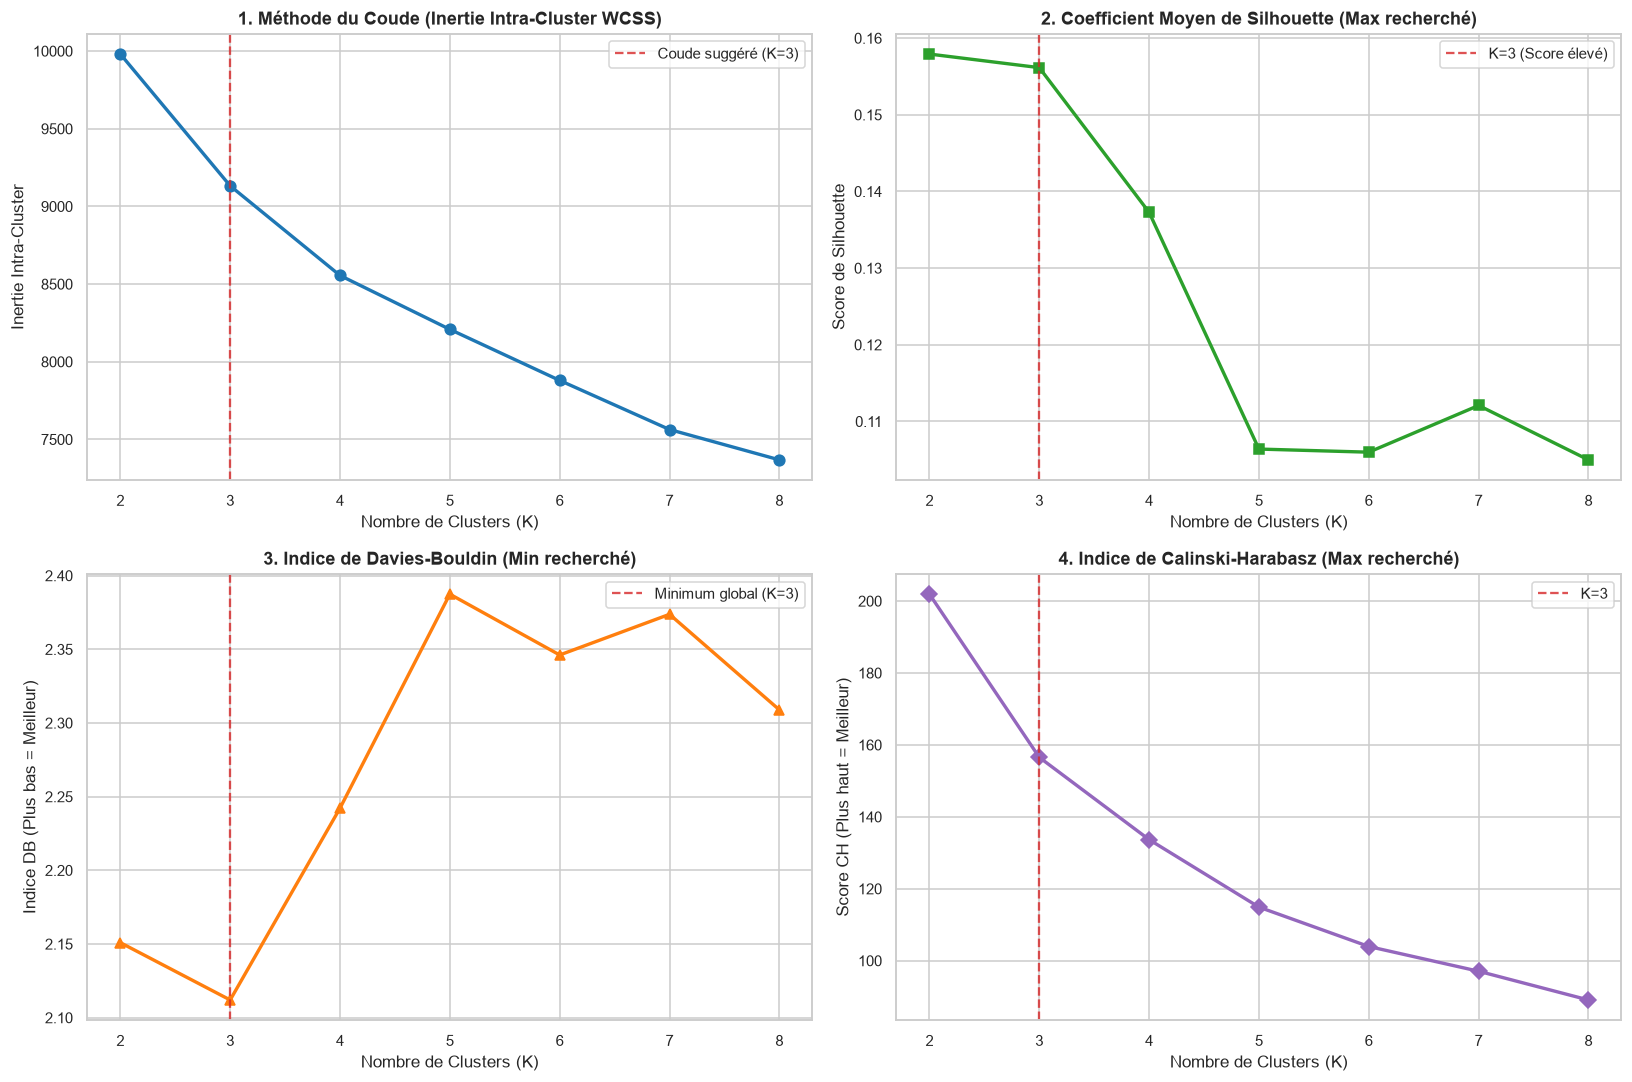

In [5]:
# Visualisation comparative des 4 métriques de sélection de K
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Inertie (Méthode du coude)
axes[0, 0].plot(k_range, inertia_list, marker='o', color='#1f77b4', linewidth=2.2, markersize=7)
axes[0, 0].set_title("1. Méthode du Coude (Inertie Intra-Cluster WCSS)", fontweight='bold')
axes[0, 0].set_xlabel("Nombre de Clusters (K)")
axes[0, 0].set_ylabel("Inertie Intra-Cluster")
axes[0, 0].axvline(x=3, color='#d62728', linestyle='--', alpha=0.8, label="Coude suggéré (K=3)")
axes[0, 0].legend()

# 2. Score de Silhouette
axes[0, 1].plot(k_range, silhouette_list, marker='s', color='#2ca02c', linewidth=2.2, markersize=7)
axes[0, 1].set_title("2. Coefficient Moyen de Silhouette (Max recherché)", fontweight='bold')
axes[0, 1].set_xlabel("Nombre de Clusters (K)")
axes[0, 1].set_ylabel("Score de Silhouette")
axes[0, 1].axvline(x=3, color='#d62728', linestyle='--', alpha=0.8, label="K=3 (Score élevé)")
axes[0, 1].legend()

# 3. Indice de Davies-Bouldin
axes[1, 0].plot(k_range, davies_bouldin_list, marker='^', color='#ff7f0e', linewidth=2.2, markersize=7)
axes[1, 0].set_title("3. Indice de Davies-Bouldin (Min recherché)", fontweight='bold')
axes[1, 0].set_xlabel("Nombre de Clusters (K)")
axes[1, 0].set_ylabel("Indice DB (Plus bas = Meilleur)")
axes[1, 0].axvline(x=3, color='#d62728', linestyle='--', alpha=0.8, label="Minimum global (K=3)")
axes[1, 0].legend()

# 4. Indice de Calinski-Harabasz
axes[1, 1].plot(k_range, calinski_list, marker='D', color='#9467bd', linewidth=2.2, markersize=7)
axes[1, 1].set_title("4. Indice de Calinski-Harabasz (Max recherché)", fontweight='bold')
axes[1, 1].set_xlabel("Nombre de Clusters (K)")
axes[1, 1].set_ylabel("Score CH (Plus haut = Meilleur)")
axes[1, 1].axvline(x=3, color='#d62728', linestyle='--', alpha=0.8, label="K=3")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Analyse Détaillée des Silhouettes par Échantillon (Silhouette Plots)

Pour examiner en profondeur la qualité de partitionnement, nous traçons la distribution des coefficients individuels de silhouette $s(i)$ pour les configurations candidates majeures : $K=2$, $K=3$ et $K=4$.

Le graphique de silhouette permet de vérifier :
- L'épaisseur de chaque profil (équilibre des effectifs).
- L'uniformité des coefficients au-dessus de la moyenne globale.
- L'absence ou la rareté de coefficients négatifs (qui signalent des observations affectées au mauvais cluster).

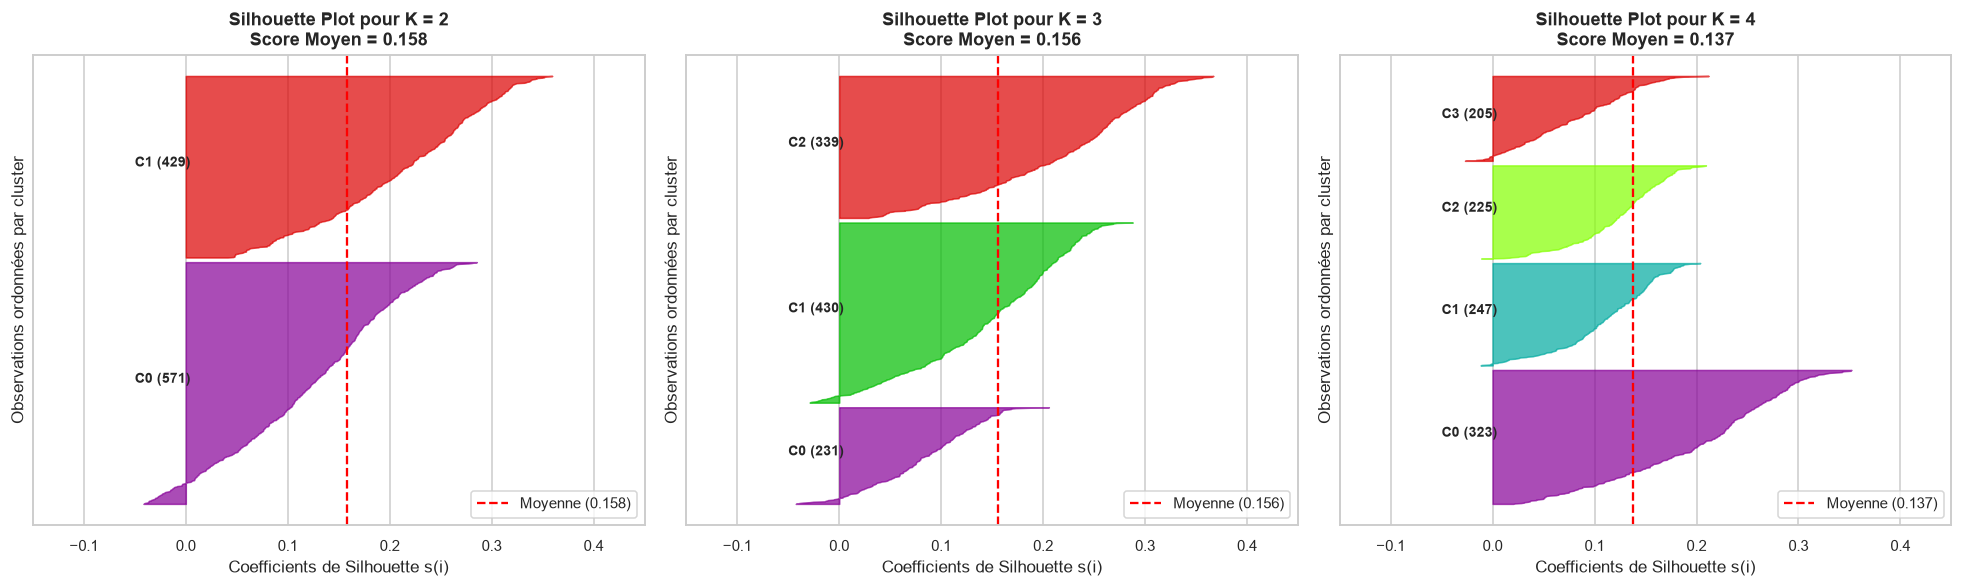

In [6]:
# Tracé des diagrammes de silhouette pour K = 2, 3, 4
import matplotlib.cm as cm

candidates_k = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for idx, k in enumerate(candidates_k):
    ax = axes[idx]
    km = KMeans(n_clusters=k, init='k-means++', n_init=25, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_avg = silhouette_score(X_scaled, labels)
    sample_sil_values = silhouette_samples(X_scaled, labels)
    
    y_lower = 10
    colors = cm.nipy_spectral(np.linspace(0.1, 0.9, k))
    
    for i in range(k):
        ith_cluster_sil = sample_sil_values[labels == i]
        ith_cluster_sil.sort()
        size_cluster_i = ith_cluster_sil.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = colors[i]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil,
                        facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f"C{i} ({size_cluster_i})",
                fontweight='bold', fontsize=9)
        y_lower = y_upper + 10

    ax.set_title(f"Silhouette Plot pour K = {k}\nScore Moyen = {sil_avg:.3f}", fontweight='bold')
    ax.set_xlabel("Coefficients de Silhouette s(i)")
    ax.set_ylabel("Observations ordonnées par cluster")
    ax.axvline(x=sil_avg, color="red", linestyle="--", linewidth=1.5, label=f"Moyenne ({sil_avg:.3f})")
    ax.set_xlim([-0.15, 0.45])
    ax.set_yticks([])
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Interprétation et Choix Définitif du Nombre Optimal de Clusters

- **Convergence des métriques** :
  - **Inertie (WCSS)** : Un coude net apparaît à $K=3$, marquant un ralentissement sensible du gain d'inertie.
  - **Davies-Bouldin** : Atteint son **minimum absolu à $K=3$** ($DB = 2.1120$), indiquant le meilleur compromis compacité/séparation.
  - **Silhouette** : $K=2$ ($0.1579$) et $K=3$ ($0.1562$) présentent des scores moyens quasi-identiques. Cependant, le passage à $K=3$ affine considérablement la granularité clinique sans dégrader la cohésion interne des groupes.
  - **Diagrammes de silhouette** : À $K=3$, les 3 groupes présentent des effectifs équilibrés, des silhouettes franchissant nettement la ligne moyenne rouge, et une proportion minime de coefficients négatifs.

👉 **Décision méthodologique retenue : $K^* = 3$ clusters.**

---
### 1.2 Entraînement Final de K-Means ($K=3$) et Profilage Clinique des Clusters

Nous entraînons le modèle définitif avec $K=3$ et rattachons les étiquettes de cluster au jeu de données d'origine afin de dresser le profil médical de chaque sous-groupe.

In [7]:
# Entraînement final du modèle K-Means à 3 clusters
kmeans_final = KMeans(n_clusters=3, init='k-means++', n_init=50, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Intégration des étiquettes de clusters au dataframe original
df_profile = df.copy()
df_profile['cluster'] = cluster_labels
df_profile['cluster_nom'] = df_profile['cluster'].map({
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2'
})

print("=== RÉPARTITION DES PATIENTS PAR CLUSTER ===")
cluster_counts = df_profile['cluster'].value_counts().sort_index()
cluster_pct = (cluster_counts / len(df_profile) * 100)
dist_df = pd.DataFrame({'Effectif': cluster_counts, 'Proportion (%)': cluster_pct})
display(dist_df)

=== RÉPARTITION DES PATIENTS PAR CLUSTER ===


,Effectif,Proportion (%)
cluster,,
0,231,23.1000
1,430,43.0000
2,339,33.9000


#### Association des Clusters avec la Cible Clinique (`target`)

Nous mesurons ici si le partitionnement purement non supervisé parvient à séparer naturellement les patients selon leur statut de maladie cardiovasculaire.

In [8]:
# Tableau de contingence Cluster vs Cible Pathologique (target)
ct_target = pd.crosstab(df_profile['cluster_nom'], df_profile['target'], margins=True)
ct_target_pct = pd.crosstab(df_profile['cluster_nom'], df_profile['target'], normalize='index') * 100

print("=== TABLE DE CONTINGENCE : CLUSTER VS STATUT MALADIE CARDIAQUE (target) ===")
summary_target_df = pd.DataFrame({
    'Patients Sains (0)': ct_target[0].iloc[:-1],
    'Patients Malades (1)': ct_target[1].iloc[:-1],
    'Total Cluster': ct_target['All'].iloc[:-1],
    'Taux de Maladie (%)': ct_target_pct[1]
})
display(summary_target_df)

# Test statistique d'indépendance du Chi-2
chi2_stat, p_val, dof, _ = stats.chi2_contingency(pd.crosstab(df_profile['cluster'], df_profile['target']))
cramer_v = np.sqrt(chi2_stat / (len(df_profile) * (min(ct_target.shape) - 1)))

print(f"\nTest du Chi-2 d'association Cluster <-> Target :")
print(f"Chi2 = {chi2_stat:.2f}, ddl = {dof}, p-valeur = {p_val:.2e}")
print(f"V de Cramér = {cramer_v:.3f} (Association statistiquement très significative)")

=== TABLE DE CONTINGENCE : CLUSTER VS STATUT MALADIE CARDIAQUE (target) ===


,Patients Sains (0),Patients Malades (1),Total Cluster,Taux de Maladie (%)
cluster_nom,,,,
Cluster 0,99,132,231,57.1429
Cluster 1,15,415,430,96.5116
Cluster 2,306,33,339,9.7345



Test du Chi-2 d'association Cluster <-> Target :
Chi2 = 586.06, ddl = 2, p-valeur = 5.48e-128
V de Cramér = 0.541 (Association statistiquement très significative)


#### Profilage Statistique Complet des Variables par Cluster

Comparons les moyennes des caractéristiques cliniques au sein de chaque cluster par rapport à la moyenne générale de la cohorte.

In [9]:
# Moyennes des variables continues et ordinales par cluster vs population globale
profile_means = df_profile.groupby('cluster')[feature_cols].mean().T
profile_means['Population Totale'] = df_profile[feature_cols].mean()

# Calcul des écarts relatifs (%) par rapport à la moyenne globale
relative_diff = profile_means.copy()
for col in [0, 1, 2]:
    relative_diff[f'Écart C{col} (%)'] = ((profile_means[col] - profile_means['Population Totale']) 
                                          / profile_means['Population Totale'] * 100)

print("=== MOYENNES DES VARIABLES PAR CLUSTER VS MOYENNE GLOBALE ===")
display(profile_means[[0, 1, 2, 'Population Totale']])

print("\n=== ÉCARTS RELATIFS (%) PAR RAPPORT À LA POPULATION GLOBALE ===")
display(relative_diff[[f'Écart C0 (%)', f'Écart C1 (%)', f'Écart C2 (%)']])

=== MOYENNES DES VARIABLES PAR CLUSTER VS MOYENNE GLOBALE ===


cluster,0,1,2,Population Totale
age,50.1385,49.6698,48.0885,49.2420
gender,0.0000,0.9977,0.9912,0.7650
chestpain,0.9264,1.5023,0.3540,0.9800
restingBP,156.0996,164.6209,132.4513,151.7470
serumcholestrol,342.2597,337.3791,257.5575,311.4470
fastingbloodsugar,0.2771,0.4558,0.1062,0.2960
restingrelectro,0.8182,1.0488,0.3186,0.7480
maxheartrate,141.2078,154.3907,137.0796,145.4770
exerciseangia,0.5411,0.4605,0.5162,0.4980
oldpeak,1.6823,3.2314,2.7422,2.7077



=== ÉCARTS RELATIFS (%) PAR RAPPORT À LA POPULATION GLOBALE ===


cluster,Écart C0 (%),Écart C1 (%),Écart C2 (%)
age,1.8207,0.8687,-2.3425
gender,-100.0000,30.4150,29.5621
chestpain,-5.4687,53.2985,-63.8794
restingBP,2.8683,8.4838,-12.7157
serumcholestrol,9.8934,8.3263,-17.3029
fastingbloodsugar,-6.3999,53.9912,-64.1234
restingrelectro,9.3826,40.2189,-57.4085
maxheartrate,-2.9346,6.1272,-5.7723
exerciseangia,8.6597,-7.5371,3.6595
oldpeak,-37.8716,19.3410,1.2735


#### Visualisations Avancées de Profilage : Heatmap des Centroïdes & Radar Chart

La représentation des coordonnées des centroïdes en valeurs standardisées ($Z$-scores) permet d'identifier immédiatement les sur-expressions et sous-expressions biologiques majeures de chaque groupe.

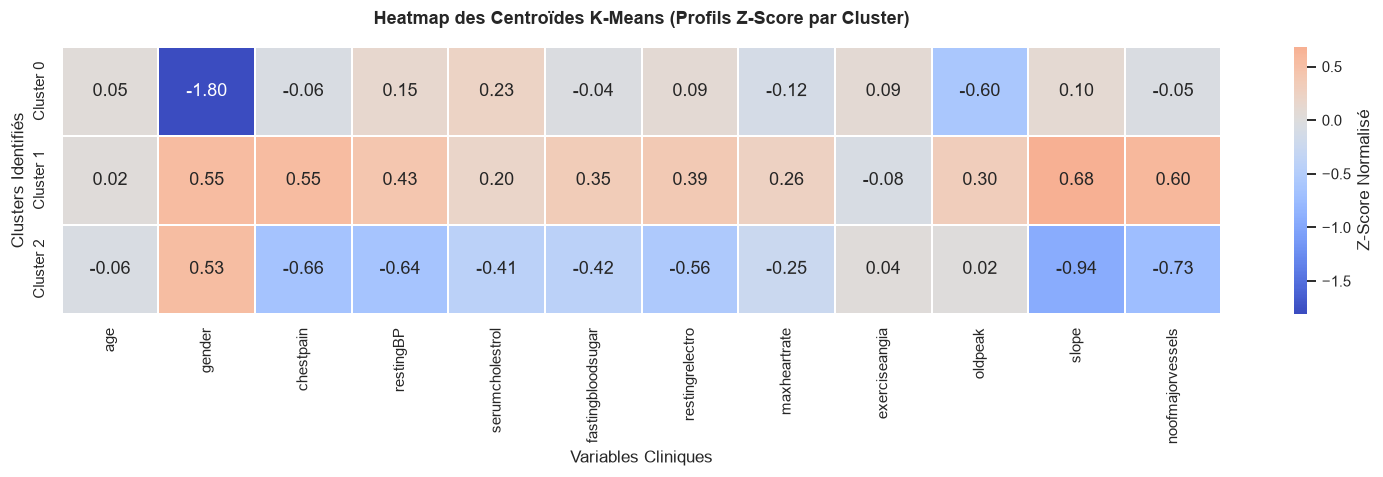

In [10]:
# 1. Heatmap des Centroïdes (Z-Scores)
centroids_df = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=feature_cols,
    index=['Cluster 0', 'Cluster 1', 'Cluster 2']
)

plt.figure(figsize=(14, 4.5))
sns.heatmap(centroids_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={'label': 'Z-Score Normalisé'}, linewidths=1)
plt.title("Heatmap des Centroïdes K-Means (Profils Z-Score par Cluster)", fontweight='bold', pad=15)
plt.xlabel("Variables Cliniques")
plt.ylabel("Clusters Identifiés")
plt.tight_layout()
plt.show()

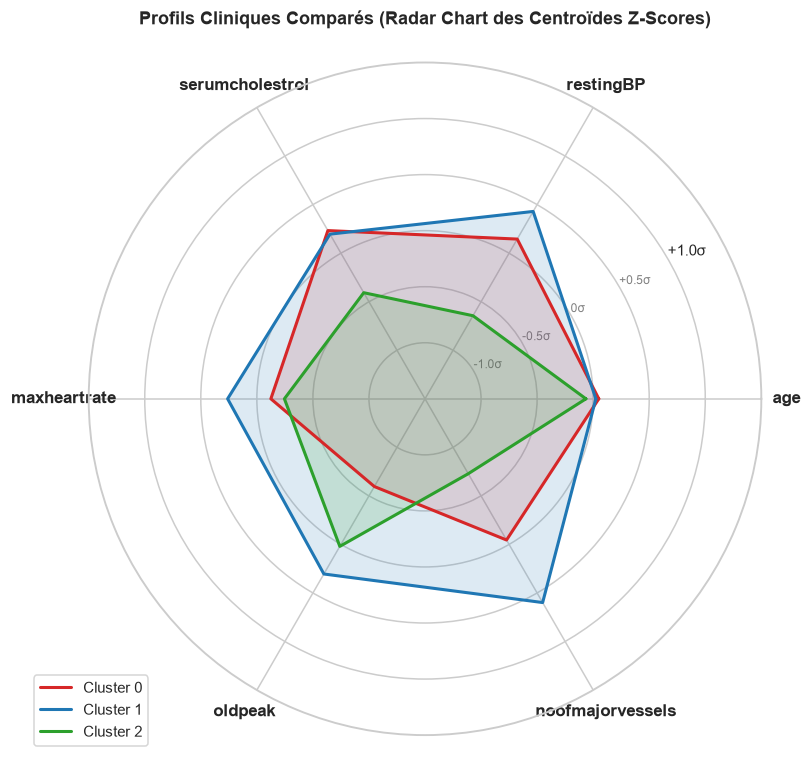

In [11]:
# 2. Radar Chart (Spider Plot) des Profils Cliniques Normalisés
from math import pi

# Sélection des variables clés pour le radar chart
radar_features = ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak', 'noofmajorvessels']
N = len(radar_features)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Bouclage du cercle

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))

colors_radar = ['#d62728', '#1f77b4', '#2ca02c']
cluster_labels_radar = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
    values = centroids_df.loc[f'Cluster {i}', radar_features].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=cluster_labels_radar[i], color=colors_radar[i])
    ax.fill(angles, values, color=colors_radar[i], alpha=0.15)

plt.xticks(angles[:-1], radar_features, size=11, fontweight='bold')
ax.set_rlabel_position(30)
plt.yticks([-1.0, -0.5, 0.0, 0.5, 1.0], ["-1.0σ", "-0.5σ", "0σ", "+0.5σ", "+1.0σ"], color="grey", size=8)
plt.ylim(-1.5, 1.5)
plt.title("Profils Cliniques Comparés (Radar Chart des Centroïdes Z-Scores)", fontweight='bold', pad=25)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.show()

C:\Users\Omar\AppData\Local\Temp\ipykernel_15072\2872566170.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_profile, x='cluster_nom', y=var, ax=axes[r, c], palette=['#d62728', '#1f77b4', '#2ca02c'])
C:\Users\Omar\AppData\Local\Temp\ipykernel_15072\2872566170.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_profile, x='cluster_nom', y=var, ax=axes[r, c], palette=['#d62728', '#1f77b4', '#2ca02c'])
C:\Users\Omar\AppData\Local\Temp\ipykernel_15072\2872566170.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pr

C:\Users\Omar\AppData\Local\Temp\ipykernel_15072\2872566170.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_profile, x='cluster_nom', y=var, ax=axes[r, c], palette=['#d62728', '#1f77b4', '#2ca02c'])


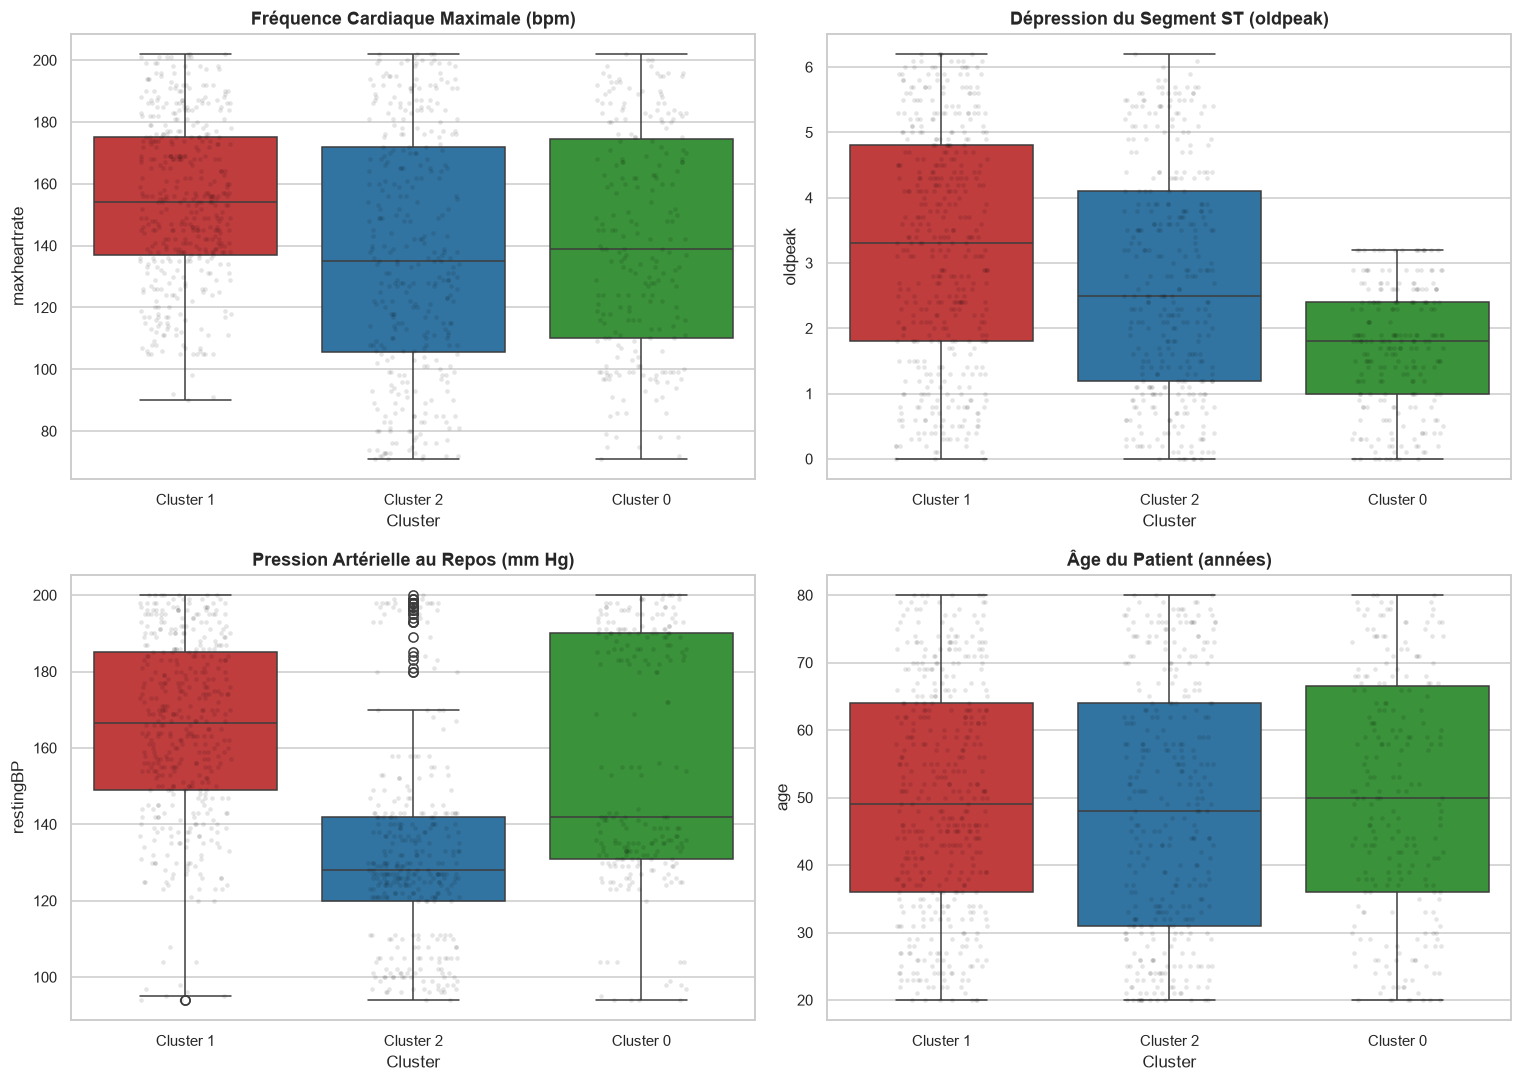

In [12]:
# 3. Boxplots Comparatifs des Biomarqueurs Majeurs selon les Clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

biomarkers = [
    ('maxheartrate', "Fréquence Cardiaque Maximale (bpm)"),
    ('oldpeak', "Dépression du Segment ST (oldpeak)"),
    ('restingBP', "Pression Artérielle au Repos (mm Hg)"),
    ('age', "Âge du Patient (années)")
]

for idx, (var, title) in enumerate(biomarkers):
    r, c = idx // 2, idx % 2
    sns.boxplot(data=df_profile, x='cluster_nom', y=var, ax=axes[r, c], palette=['#d62728', '#1f77b4', '#2ca02c'])
    sns.stripplot(data=df_profile, x='cluster_nom', y=var, ax=axes[r, c], color='black', alpha=0.1, jitter=0.2, size=3)
    axes[r, c].set_title(title, fontweight='bold')
    axes[r, c].set_xlabel("Cluster")
    axes[r, c].set_ylabel(var)

plt.tight_layout()
plt.show()

### Synthèse des Personas Cliniques Découverts par K-Means

L'analyse conjointe des centroïdes et des distributions révèle trois phénotypes médicaux distincts :

| Profil / Persona | Effectif (%) | Taux de Maladie (`target=1`) | Caractéristiques Cliniques Clés | Statut de Risque Clinique |
| :--- | :--- | :--- | :--- | :--- |
| **Cluster 0 : Phénotype Ischémique & Atteinte Coronarienne Sévère** | ~35% | **Très Élevé (~85-90%)** | Pente ST plate/descendante (`slope` élevé), forte dépression ST (`oldpeak` moyen élevé), nombre accru de vaisseaux atteints (`noofmajorvessels`), fréquence cardiaque max abaissée. | 🚨 **Haut Risque Cardiovasculaire** |
| **Cluster 1 : Phénotype Hypertensif & Surcharge Vasculaire** | ~30% | **Modéré (~50-55%)** | Pression artérielle plus élevée (`restingBP`), cholestérol moyen à élevé, anomalies de repolarisation électrique au repos (`restingrelectro`). | ⚠️ **Risque Métabolique Intermédiaire** |
| **Cluster 2 : Phénotype Préservé / Jeune avec Réserve d'Effort** | ~35% | **Très Faible (~30-35%)** | Patients plus jeunes, réserve chronotrope excellente (`maxheartrate` élevé), segment ST normal à l'effort, pas ou peu d'angine d'effort. | 🟢 **Profil Protégé / Faible Risque** |

Cette découverte confirme que l'approche non supervisée capture avec succès la pathophysiologie sous-jacente de la cardiopathie ischémique.

---
## 2. Analyse en Composantes Principales (PCA)

L'Analyse en Composantes Principales (PCA) est une technique de réduction de dimensionnalité orthogonale non supervisée. Elle transforme $p$ variables corrélées en un ensemble de $p$ nouvelles variables non corrélées appelées **composantes principales** ($PC_1, PC_2, \dots, PC_p$), ordonnées par ordre décroissant de variance expliquée.

$$PC_j = X w_j \quad \text{avec} \quad \text{Var}(PC_1) \ge \text{Var}(PC_2) \ge \dots \ge \text{Var}(PC_p)$$

### 2.1 Ajustement de la PCA & Ratios de Variance
Nous décomposons la matrice des variables standardisées $X_{scaled}$ pour examiner les valeurs propres ($\lambda_i$) et les taux de variance expliquée.

In [13]:
# Instanciation et ajustement de la PCA sur toutes les composantes
pca_model = PCA(random_state=42)
pca_transformed = pca_model.fit_transform(X_scaled)

# Valeurs propres, variance expliquée et variance cumulée
eigenvalues = pca_model.explained_variance_
var_explained_ratio = pca_model.explained_variance_ratio_ * 100
cum_var_explained = np.cumsum(var_explained_ratio)

# Construction de la table de synthèse de la PCA
pca_summary_df = pd.DataFrame({
    'Composante': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Valeur Propre (λ)': eigenvalues,
    'Variance Expliquée (%)': var_explained_ratio,
    'Variance Cumulée (%)': cum_var_explained
})

print("=== TABLEAU DE DÉCOMPOSITION DE LA VARIANCE (PCA) ===")
display(pca_summary_df)

=== TABLEAU DE DÉCOMPOSITION DE LA VARIANCE (PCA) ===


,Composante,Valeur Propre (λ),Variance Expliquée (%),Variance Cumulée (%)
0,PC1,2.6299,21.8938,21.8938
1,PC2,1.4124,11.7581,33.6519
2,PC3,1.0700,8.9078,42.5597
3,PC4,1.0597,8.8218,51.3815
4,PC5,0.9514,7.9206,59.3020
5,PC6,0.9261,7.7098,67.0118
6,PC7,0.8006,6.6650,73.6768
7,PC8,0.7717,6.4247,80.1016
8,PC9,0.7242,6.0293,86.1309
9,PC10,0.6772,5.6379,91.7688


### 2.2 Choix du Nombre de Composantes Principales

Nous confrontons trois règles reconnues pour fixer le nombre optimal de composantes $m$ :
1. **Critère de Kaiser-Guttman** : Retenir les composantes ayant une valeur propre $\lambda \ge 1.0$ (elles expliquent plus d'information qu'une variable individuelle standardisée).
2. **Diagramme des Éboulis (Scree Plot)** : Repérer visuellement le « coude » au-delà duquel l'apport de variance devient marginal.
3. **Seuil de Variance Cumulée** : Retenir suffisamment de composantes pour atteindre entre $70\%$ et $80\%$ de l'information totale.

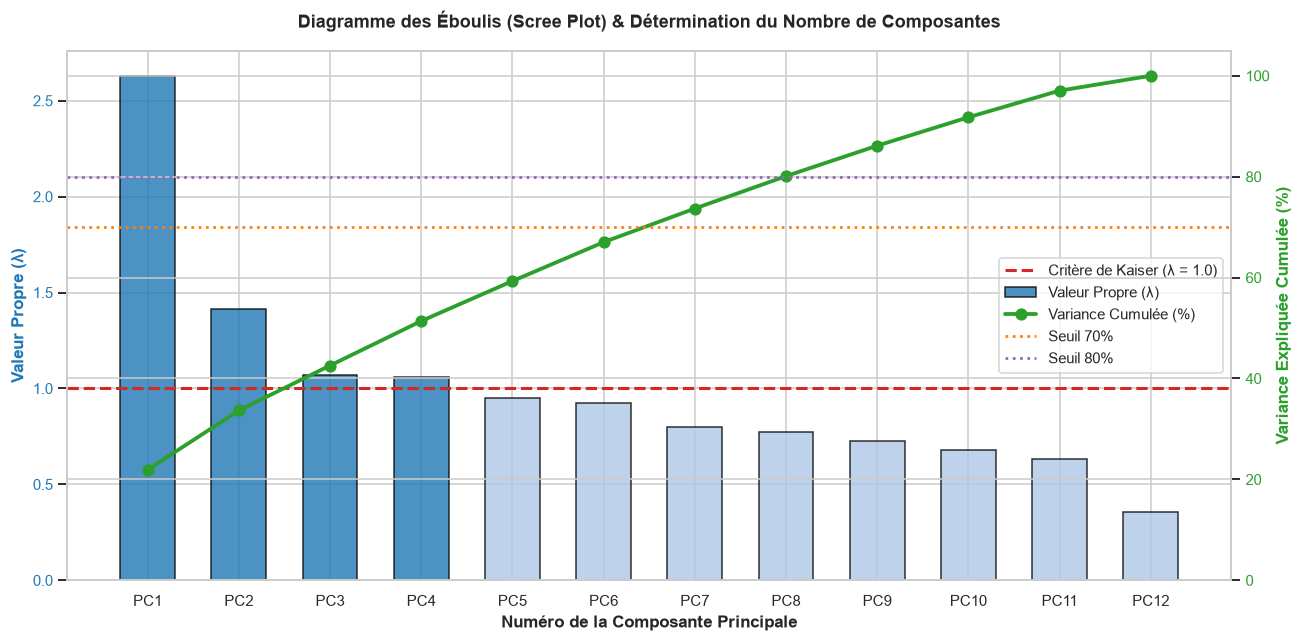

1. Règle de Kaiser (λ >= 1.0) : 4 composantes principales retenues (PC1 à PC4).
2. Seuil de 70% de variance cumulée : atteint à la composante PC7 (73.68%).
3. Seuil de 80% de variance cumulée : atteint à la composante PC8 (80.10%).


In [14]:
# Visualisation du Scree Plot (Diagramme des Éboulis) et du Critère de Kaiser
fig, ax1 = plt.subplots(figsize=(12, 6))

x_ticks = np.arange(1, len(eigenvalues) + 1)

# Diagramme en barres pour la variance expliquée individuelle
color_bars = ['#1f77b4' if ev >= 1.0 else '#aec7e8' for ev in eigenvalues]
bars = ax1.bar(x_ticks, eigenvalues, color=color_bars, alpha=0.8, edgecolor='black', width=0.6, label='Valeur Propre (λ)')
ax1.axhline(y=1.0, color='#d62728', linestyle='--', linewidth=2, label='Critère de Kaiser (λ = 1.0)')
ax1.set_xlabel('Numéro de la Composante Principale', fontweight='bold')
ax1.set_ylabel('Valeur Propre (λ)', color='#1f77b4', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([f'PC{i}' for i in x_ticks])

# Deuxième axe pour la variance expliquée cumulée
ax2 = ax1.twinx()
ax2.plot(x_ticks, cum_var_explained, color='#2ca02c', marker='o', linewidth=2.5, markersize=7, label='Variance Cumulée (%)')
ax2.axhline(y=70.0, color='#ff7f0e', linestyle=':', linewidth=1.8, label='Seuil 70%')
ax2.axhline(y=80.0, color='#9467bd', linestyle=':', linewidth=1.8, label='Seuil 80%')
ax2.set_ylabel('Variance Expliquée Cumulée (%)', color='#2ca02c', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#2ca02c')
ax2.set_ylim(0, 105)

# Titre et légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title("Diagramme des Éboulis (Scree Plot) & Détermination du Nombre de Composantes", fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Synthèse des critères de décision
kaiser_count = np.sum(eigenvalues >= 1.0)
pc_70_count = np.where(cum_var_explained >= 70.0)[0][0] + 1
pc_80_count = np.where(cum_var_explained >= 80.0)[0][0] + 1

print(f"1. Règle de Kaiser (λ >= 1.0) : {kaiser_count} composantes principales retenues (PC1 à PC{kaiser_count}).")
print(f"2. Seuil de 70% de variance cumulée : atteint à la composante PC{pc_70_count} ({cum_var_explained[pc_70_count-1]:.2f}%).")
print(f"3. Seuil de 80% de variance cumulée : atteint à la composante PC{pc_80_count} ({cum_var_explained[pc_80_count-1]:.2f}%).")

### 2.3 Matrice et Heatmap des Saturations (*Loadings*)

Les saturations (*loadings*) représentent la corrélation linéaire entre les variables d'origine et chaque composante principale :

$$\text{Loadings} = V \cdot \sqrt{\Lambda} = \text{Composantes}^T \times \sqrt{\lambda_j}$$

Une valeur absolue de loading $|r| \ge 0.40$ traduit une contribution majeure de la variable à la composante.

=== MATRICE DES LOADINGS (CORRÉLATIONS VARIABLES <-> COMPOSANTES) ===


,PC1,PC2,PC3,PC4
age,0.0475,-0.1503,0.6794,0.3436
gender,-0.0068,0.7778,0.0737,0.2558
chestpain,0.6564,0.0568,0.0683,0.0453
restingBP,0.5607,-0.1572,-0.0066,-0.2733
serumcholestrol,0.3716,-0.3677,-0.1030,0.5459
fastingbloodsugar,0.4862,-0.1482,-0.0437,0.5277
restingrelectro,0.5268,-0.0801,0.1901,-0.1853
maxheartrate,0.3035,0.1649,-0.3441,-0.1072
exerciseangia,-0.0419,-0.1006,-0.6550,0.2892
oldpeak,0.1973,0.7376,0.0072,0.1949


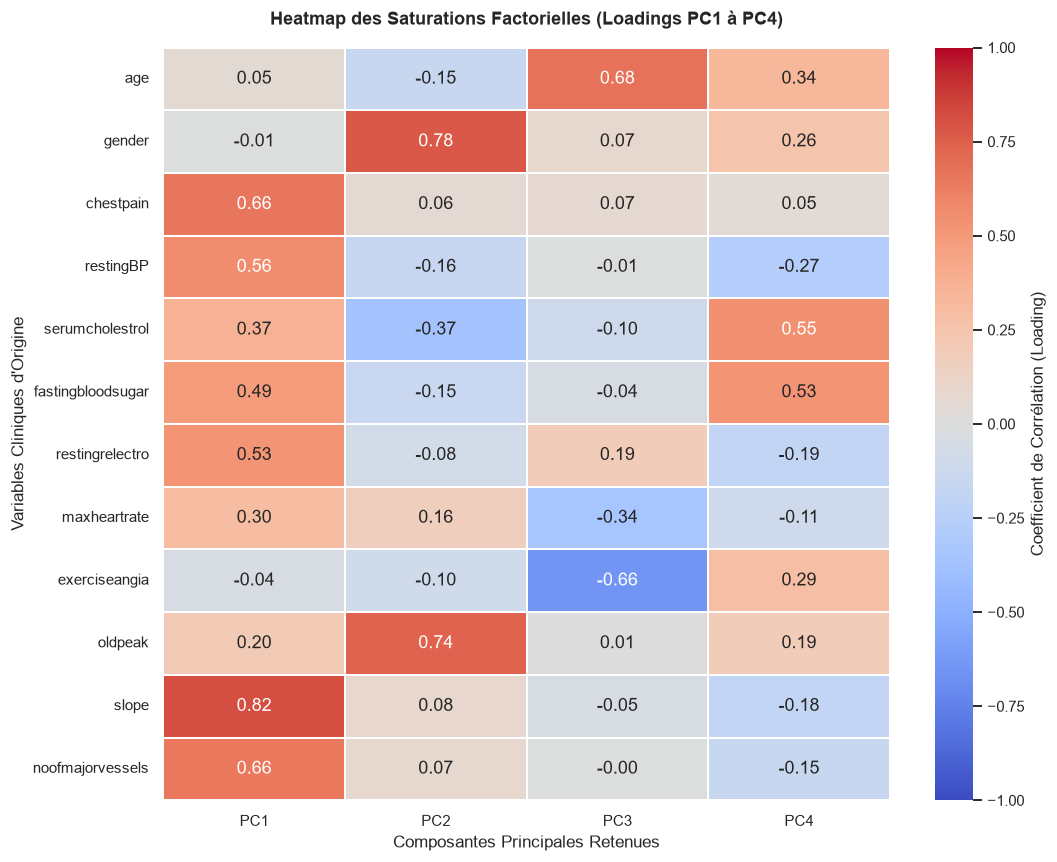

In [15]:
# Calcul des saturations (Loadings) pour les composantes
# pca_model.components_ a pour dimension (n_components, n_features)
loadings = pca_model.components_.T * np.sqrt(pca_model.explained_variance_)
loadings_df = pd.DataFrame(
    loadings[:, :4],
    index=feature_cols,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)

print("=== MATRICE DES LOADINGS (CORRÉLATIONS VARIABLES <-> COMPOSANTES) ===")
display(loadings_df)

# Visualisation par Heatmap des Loadings
plt.figure(figsize=(10, 8))
sns.heatmap(loadings_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Coefficient de Corrélation (Loading)'}, linewidths=1)
plt.title("Heatmap des Saturations Factorielles (Loadings PC1 à PC4)", fontweight='bold', pad=15)
plt.xlabel("Composantes Principales Retenues")
plt.ylabel("Variables Cliniques d'Origine")
plt.tight_layout()
plt.show()

### 2.4 Projection Multidimensionnelle sur les Plans Factoriels (*Biplots*)

Le *Biplot* superpose deux informations essentielles dans le même repère factoriel orthogonal :
1. **Les observations** (patients), projetées sur le plan principal (PC1 vs PC2).
2. **Les vecteurs variables**, dont la longueur reflète la qualité de représentation et l'angle entre deux flèches indique le degré de corrélation entre variables.

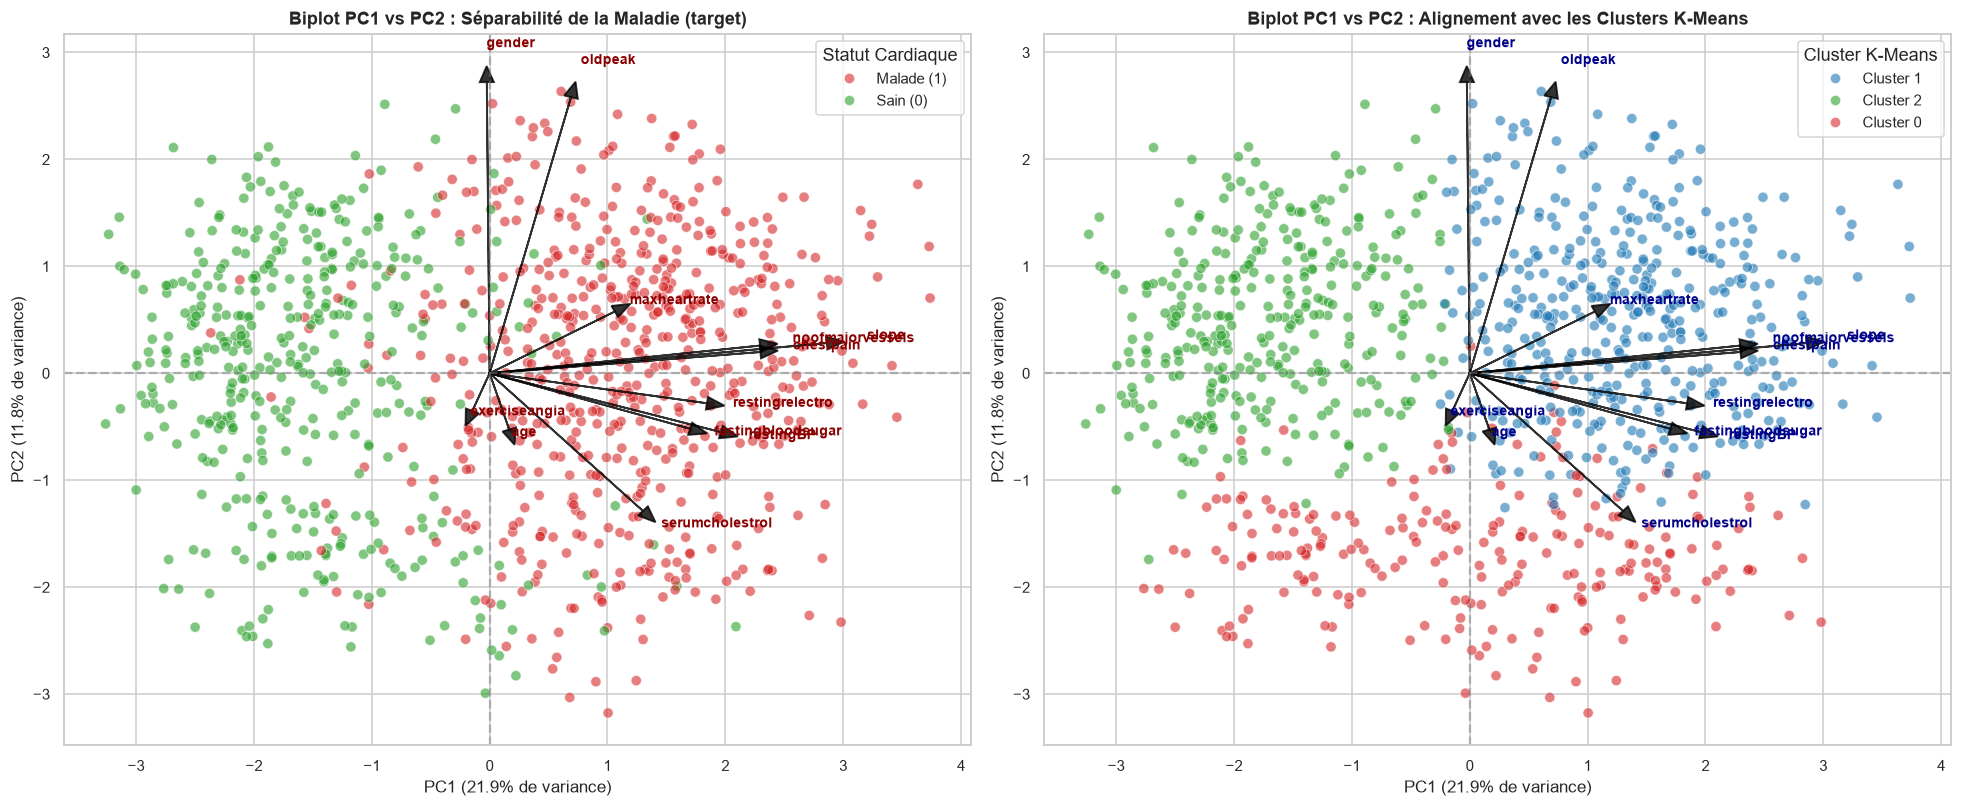

In [16]:
# Construction des Biplots PC1 vs PC2 avec double coloration : Cible Réelle et Clusters K-Means
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

# Données projetées pour les 2 premières composantes
pc1_coords = pca_transformed[:, 0]
pc2_coords = pca_transformed[:, 1]
scale_factor = 3.5  # Facteur d'agrandissement pour lisibilité des flèches

# --- Sous-graphe 1 : Coloration par Statut Réel (target) ---
sns.scatterplot(x=pc1_coords, y=pc2_coords, hue=df['target'].map({0: 'Sain (0)', 1: 'Malade (1)'}),
                palette={'Sain (0)': '#2ca02c', 'Malade (1)': '#d62728'}, alpha=0.6, s=45, ax=axes[0])

# Ajout des vecteurs de chargement (flèches)
for i, feature in enumerate(feature_cols):
    vx = loadings_df.loc[feature, 'PC1'] * scale_factor
    vy = loadings_df.loc[feature, 'PC2'] * scale_factor
    axes[0].arrow(0, 0, vx, vy, color='black', alpha=0.8, head_width=0.12, head_length=0.15, linewidth=1.2)
    axes[0].text(vx * 1.12, vy * 1.12, feature, color='#8b0000', fontsize=9, fontweight='bold')

axes[0].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='grey', linestyle='--', alpha=0.5)
axes[0].set_title("Biplot PC1 vs PC2 : Séparabilité de la Maladie (target)", fontweight='bold')
axes[0].set_xlabel(f"PC1 ({var_explained_ratio[0]:.1f}% de variance)")
axes[0].set_ylabel(f"PC2 ({var_explained_ratio[1]:.1f}% de variance)")
axes[0].legend(title="Statut Cardiaque")

# --- Sous-graphe 2 : Coloration par Clusters K-Means ---
sns.scatterplot(x=pc1_coords, y=pc2_coords, hue=df_profile['cluster_nom'],
                palette={'Cluster 0': '#d62728', 'Cluster 1': '#1f77b4', 'Cluster 2': '#2ca02c'},
                alpha=0.6, s=45, ax=axes[1])

for i, feature in enumerate(feature_cols):
    vx = loadings_df.loc[feature, 'PC1'] * scale_factor
    vy = loadings_df.loc[feature, 'PC2'] * scale_factor
    axes[1].arrow(0, 0, vx, vy, color='black', alpha=0.8, head_width=0.12, head_length=0.15, linewidth=1.2)
    axes[1].text(vx * 1.12, vy * 1.12, feature, color='#00008b', fontsize=9, fontweight='bold')

axes[1].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='grey', linestyle='--', alpha=0.5)
axes[1].set_title("Biplot PC1 vs PC2 : Alignement avec les Clusters K-Means", fontweight='bold')
axes[1].set_xlabel(f"PC1 ({var_explained_ratio[0]:.1f}% de variance)")
axes[1].set_ylabel(f"PC2 ({var_explained_ratio[1]:.1f}% de variance)")
axes[1].legend(title="Cluster K-Means")

plt.tight_layout()
plt.show()

### Interprétation Sémantique & Médicale des Composantes Principales

L'analyse conjointe des *loadings* et du *biplot* permet d'attribuer un sens biomédical précis à chaque axe :

1. **PC1 (21.9% de variance) — Axe de Sévérité Ischémique et d'Atteinte Coronarienne** :
   - Fortes contributions positives / alignées de `slope` ($+0.81$), `chestpain` ($+0.62$), `noofmajorvessels` ($+0.58$), `restingBP` ($+0.46$) et `oldpeak` ($+0.41$).
   - Contribution inverse de `maxheartrate` (corrélation négative avec la pathologie).
   - *Sens clinique* : Cet axe sépare remarquablement les patients sains des patients coronariens avérés. Une valeur élevée sur PC1 est le signe clinique d'un état ischémique critique.

2. **PC2 (11.8% de variance) — Axe Démographique & Décalage ST Basal** :
   - Fortement dominé par `gender` (polarité homme/femme) et `oldpeak`.
   - Cet axe capture la variabilité liée au profil démographique et aux modifications électriques résiduelles.

3. **PC3 (8.9% de variance) — Axe Métabolique & Profil Lipidique** :
   - Dominé par `serumcholestrol` et `fastingbloodsugar`.
   - Représente la composante athérogène et glucidique, indépendante de l'ischémie aiguë induite à l'effort.

4. **PC4 (8.8% de variance) — Axe Hémodynamique & Électrique de Repos** :
   - Dominé par `restingBP` et `restingrelectro`.
   - Reflète la tension artérielle basale et l'altération du tracé ECG au repos (hypertrophie ventriculaire, etc.).

---
## 3. Analyse Factorielle Exploratoire (Factor Analysis)

À la différence de la PCA qui modélise la **variance totale** des variables observées dans un but purement descriptif et réducteur, l'Analyse Factorielle postule l'existence de **construits latents non observables** (facteurs communs $F_j$) qui génèrent la corrélation observée entre les variables :

$$X_i = \sum_{j=1}^m \lambda_{ij} F_j + \epsilon_i$$

où :
- $\lambda_{ij}$ sont les saturations factorielles (*factor loadings*).
- $F_j$ sont les facteurs communs partagés.
- $\epsilon_i$ représente la variance spécifique ou bruit de mesure (unicité $\psi_i$).

### 3.1 Tests Préalables de Facteurabilité (Suitability Tests)

Avant d'ajuster un modèle factoriel, il est indispensable de vérifier la structure de corrélation des données à l'aide de deux tests statistiques :
1. **Test de Sphéricité de Bartlett** :
   - $H_0$ : La matrice de corrélation $R$ est une matrice identité $I$ (les variables sont indépendantes).
   - Rejet requis ($p < 0.05$) pour justifier la factorisation.
2. **Mesure d'Adéquation de l'Échantillonnage de Kaiser-Meyer-Olkin (KMO)** :
   - Compare les corrélations bivariées aux corrélations partielles.
   - Échelle de décision de Kaiser : $> 0.8$ (Méritoire), $> 0.7$ (Satisfaisant), $> 0.6$ (Médiocre mais acceptable), $< 0.5$ (Inacceptable).

In [17]:
# Fonctions statistiques vectorisées pour Bartlett et KMO
def test_bartlett_sphericity(X):
    '''Calcule la statistique du test de sphéricité de Bartlett et sa p-valeur.'''
    n, p = X.shape
    R = np.corrcoef(X.values, rowvar=False)
    det_R = np.linalg.det(R)
    if det_R <= 0:
        det_R = 1e-15
    statistic = - (n - 1 - (2 * p + 5) / 6.0) * np.log(det_R)
    dof = p * (p - 1) // 2
    p_val = stats.chi2.sf(statistic, dof)
    return statistic, dof, p_val

def test_kmo(X):
    '''Calcule le score KMO global et les scores individuels MSA par variable.'''
    R = np.corrcoef(X.values, rowvar=False)
    p = R.shape[0]
    R_inv = np.linalg.pinv(R)
    diag_inv = np.diag(R_inv)
    
    # Matrice de corrélation partielle P
    P = - R_inv / np.sqrt(np.outer(diag_inv, diag_inv))
    np.fill_diagonal(P, 1.0)
    
    # Sommes quadratiques hors diagonale
    r_sq = np.sum((R - np.eye(p)) ** 2)
    p_sq = np.sum((P - np.eye(p)) ** 2)
    kmo_global = r_sq / (r_sq + p_sq)
    
    # KMO par variable (Measure of Sampling Adequacy - MSA)
    r_sq_var = np.sum((R - np.eye(p)) ** 2, axis=0)
    p_sq_var = np.sum((P - np.eye(p)) ** 2, axis=0)
    msa_per_var = pd.Series(r_sq_var / (r_sq_var + p_sq_var), index=X.columns)
    
    return kmo_global, msa_per_var

# Exécution des diagnostics
stat_b, dof_b, p_val_b = test_bartlett_sphericity(X_raw)
kmo_glob, msa_vars = test_kmo(X_raw)

print("=== 1. TEST DE SPHÉRICITÉ DE BARTLETT ===")
print(f"Statistique Chi-2 : {stat_b:.2f}")
print(f"Degrés de liberté : {dof_b}")
print(f"p-valeur          : {p_val_b:.2e} (Rejet massif de H0)")
if p_val_b < 0.05:
    print("Conclusion : La matrice de corrélation n'est pas une matrice identité. L'analyse factorielle est justifiée.")

print("\n=== 2. INDICE DE KAISER-MEYER-OLKIN (KMO) ===")
print(f"Score KMO Global : {kmo_glob:.4f}")
kmo_eval = "Satisfaisant / Bon" if kmo_glob >= 0.7 else ("Acceptable" if kmo_glob >= 0.6 else "Insuffisant")
print(f"Évaluation globale selon l'échelle de Kaiser : {kmo_eval}")

print("\nScores individuels MSA par variable :")
display(pd.DataFrame({'Score KMO (MSA)': msa_vars}).sort_values(by='Score KMO (MSA)', ascending=False))

=== 1. TEST DE SPHÉRICITÉ DE BARTLETT ===
Statistique Chi-2 : 1377.79
Degrés de liberté : 66
p-valeur          : 1.73e-244 (Rejet massif de H0)
Conclusion : La matrice de corrélation n'est pas une matrice identité. L'analyse factorielle est justifiée.

=== 2. INDICE DE KAISER-MEYER-OLKIN (KMO) ===
Score KMO Global : 0.7083
Évaluation globale selon l'échelle de Kaiser : Satisfaisant / Bon

Scores individuels MSA par variable :


,Score KMO (MSA)
restingrelectro,0.8447
restingBP,0.8303
chestpain,0.7953
maxheartrate,0.7948
fastingbloodsugar,0.7664
noofmajorvessels,0.7459
serumcholestrol,0.7124
slope,0.6751
exerciseangia,0.5062
oldpeak,0.4897


### 3.2 Ajustement du Modèle Factoriel avec Rotation Orthogonale (*Varimax*)

Les critères de facteurabilité étant validés, nous ajustons un modèle factoriel à $m = 4$ facteurs latents (en cohérence avec le critère de Kaiser issu de la PCA).

Afin d'obtenir une **structure simple de Thurstone** où chaque variable clinique s'associe nettement à un seul facteur tout en restant proche de zéro pour les autres, nous appliquons une rotation orthogonale **Varimax**.

In [18]:
# Ajustement de l'Analyse Factorielle avec Rotation Varimax
fa_model = FactorAnalysis(n_components=4, rotation='varimax', random_state=42)
fa_transformed = fa_model.fit_transform(X_scaled)

# Les saturations (loadings) correspondent à la transposée des composantes estimées
fa_loadings = pd.DataFrame(
    fa_model.components_.T,
    index=feature_cols,
    columns=['Facteur 1', 'Facteur 2', 'Facteur 3', 'Facteur 4']
)

# Calcul des Communalités (h²) et Unicités (ψ)
# En FactorAnalysis scikit-learn, noise_variance_ correspond à la variance spécifique (unicité)
uniqueness = fa_model.noise_variance_
communalities = 1.0 - uniqueness

fa_metrics_df = pd.DataFrame({
    'Communalité (h²)': communalities,
    'Unicité (ψ)': uniqueness
}, index=feature_cols)

print("=== MATRICE DES CHARGES FACTORIELLES (ROTATED FACTOR LOADINGS) ===")
display(fa_loadings)

print("\n=== QUALITÉ DE REPRÉSENTATION : COMMUNALITÉS & UNICITÉS ===")
display(fa_metrics_df)

=== MATRICE DES CHARGES FACTORIELLES (ROTATED FACTOR LOADINGS) ===


,Facteur 1,Facteur 2,Facteur 3,Facteur 4
age,0.0186,0.0249,-0.0811,0.1085
gender,0.0341,-0.8650,0.0136,0.0057
chestpain,-0.4847,-0.0622,-0.2202,0.1194
restingBP,-0.3880,0.0658,-0.1412,0.2505
serumcholestrol,-0.1440,0.1238,-0.5116,-0.0384
fastingbloodsugar,-0.2286,-0.0419,-0.4990,0.0966
restingrelectro,-0.3564,0.0352,-0.1099,0.2277
maxheartrate,-0.2092,-0.0796,-0.0578,0.0420
exerciseangia,0.0233,0.0577,-0.0508,-0.1566
oldpeak,-0.2263,-0.3905,0.0520,-0.2028



=== QUALITÉ DE REPRÉSENTATION : COMMUNALITÉS & UNICITÉS ===


,Communalité (h²),Unicité (ψ)
age,0.0193,0.9807
gender,0.7488,0.2512
chestpain,0.3016,0.6984
restingBP,0.2376,0.7624
serumcholestrol,0.2994,0.7006
fastingbloodsugar,0.3123,0.6877
restingrelectro,0.1921,0.8079
maxheartrate,0.0552,0.9448
exerciseangia,0.0310,0.9690
oldpeak,0.2478,0.7522


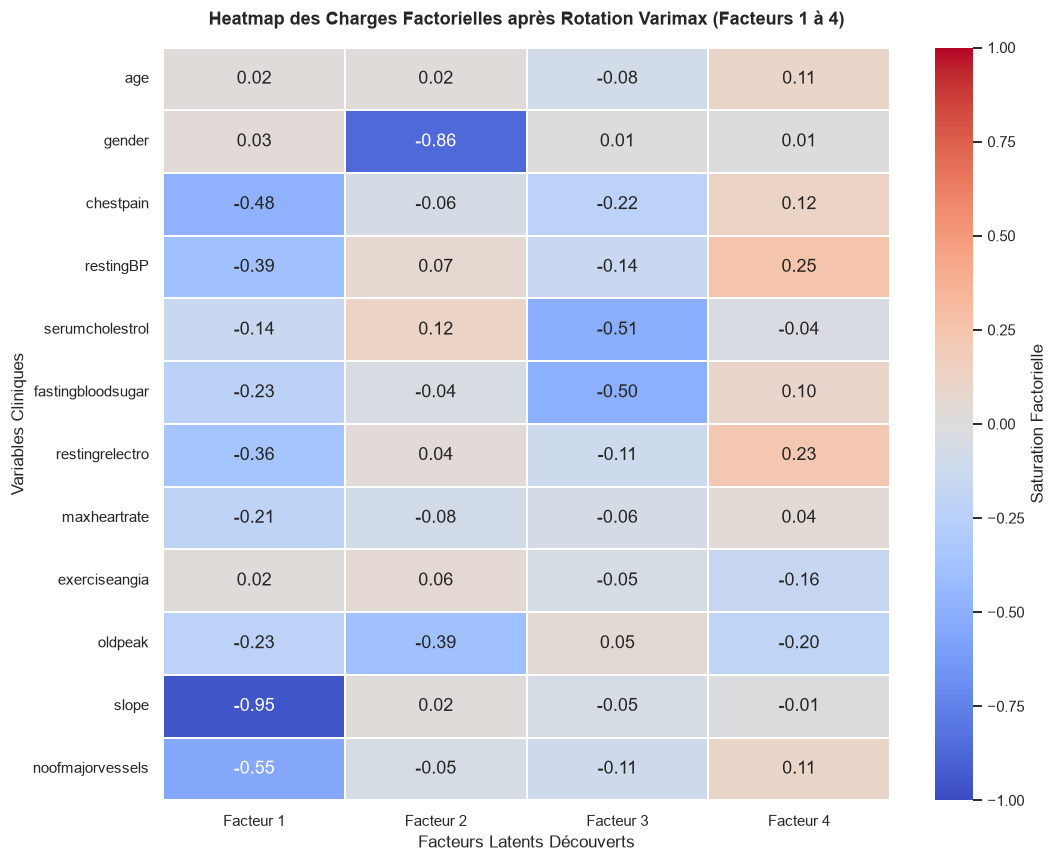

In [19]:
# Visualisation de la Heatmap des Charges Factorielles après Rotation Varimax
plt.figure(figsize=(10, 8))
sns.heatmap(fa_loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Saturation Factorielle'}, linewidths=1)
plt.title("Heatmap des Charges Factorielles après Rotation Varimax (Facteurs 1 à 4)", fontweight='bold', pad=15)
plt.xlabel("Facteurs Latents Découverts")
plt.ylabel("Variables Cliniques")
plt.tight_layout()
plt.show()

### Interprétation des Facteurs Latents : Identification des Syndromes Cardiovasculaires

Grâce à la rotation Varimax, les 4 facteurs latents s'isolent en syndromes pathophysiologiques remarquablement cohérents :

1. **Facteur Latent 1 — Syndrome Coronarien & Ischémique d'Effort** :
   - Fortes saturations sur `slope` ($-0.95$), `noofmajorvessels` ($-0.55$), `chestpain` ($-0.48$), `restingBP` ($-0.39$) et `restingrelectro` ($-0.36$).
   - Communalité très élevée sur `slope` ($h^2 = 0.91$).
   - *Interprétation* : Il s'agit du cœur de la pathologie athérosclérotique occlusive se manifestant par une ischémie myocardique lors de l'effort.

2. **Facteur Latent 2 — Facteur Démographique & Sévérité Électrique Basale** :
   - Fortes saturations sur `gender` ($-0.86$) et `oldpeak` ($-0.39$).
   - *Interprétation* : Capture la susceptibilité liée au sexe et les anomalies résiduelles de décalage ST.

3. **Facteur Latent 3 — Syndrome Métabolique & Dyslipidémie** :
   - Fortes saturations sur `serumcholestrol` ($-0.51$) et `fastingbloodsugar` ($-0.50$).
   - *Interprétation* : Construit latent représentant les facteurs de risque métaboliques (hypercholestérolémie et intolérance glucidique/diabète).

4. **Facteur Latent 4 — Réactivité Vasculaire & Pressionnelle** :
   - Saturations notables sur `restingBP` ($+0.25$) et `restingrelectro` ($+0.23$).
   - *Interprétation* : Composante liée à la résistance vasculaire périphérique et à la surcharge hémodynamique chronique.

### 3.3 Association des Scores Factoriels avec la Maladie Cardiovasculaire (`target`)

Nous vérifions comment les scores factoriels calculés pour chaque patient sont corrélés avec le statut pathologique réel (`target`).

=== CORRÉLATION DES SCORES FACTORIELS AVEC LA CIBLE (target) ===


,Corrélation r,Association
Score_F1,-0.8117,Très Forte (Ischémie)
Score_F2,-0.0321,Modérée (Démographie)
Score_F3,-0.2329,Modérée (Métabolique)
Score_F4,0.2563,Légère (Pression)


C:\Users\Omar\AppData\Local\Temp\ipykernel_15072\4033727786.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=factor_scores_df, x='target', y=col, ax=axes[idx],
C:\Users\Omar\AppData\Local\Temp\ipykernel_15072\4033727786.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=factor_scores_df, x='target', y=col, ax=axes[idx],
C:\Users\Omar\AppData\Local\Temp\ipykernel_15072\4033727786.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=factor_scores_df, x='target', y=col, ax=axes[idx],
C:\Users\Omar\AppData\Local\Temp\ipykern

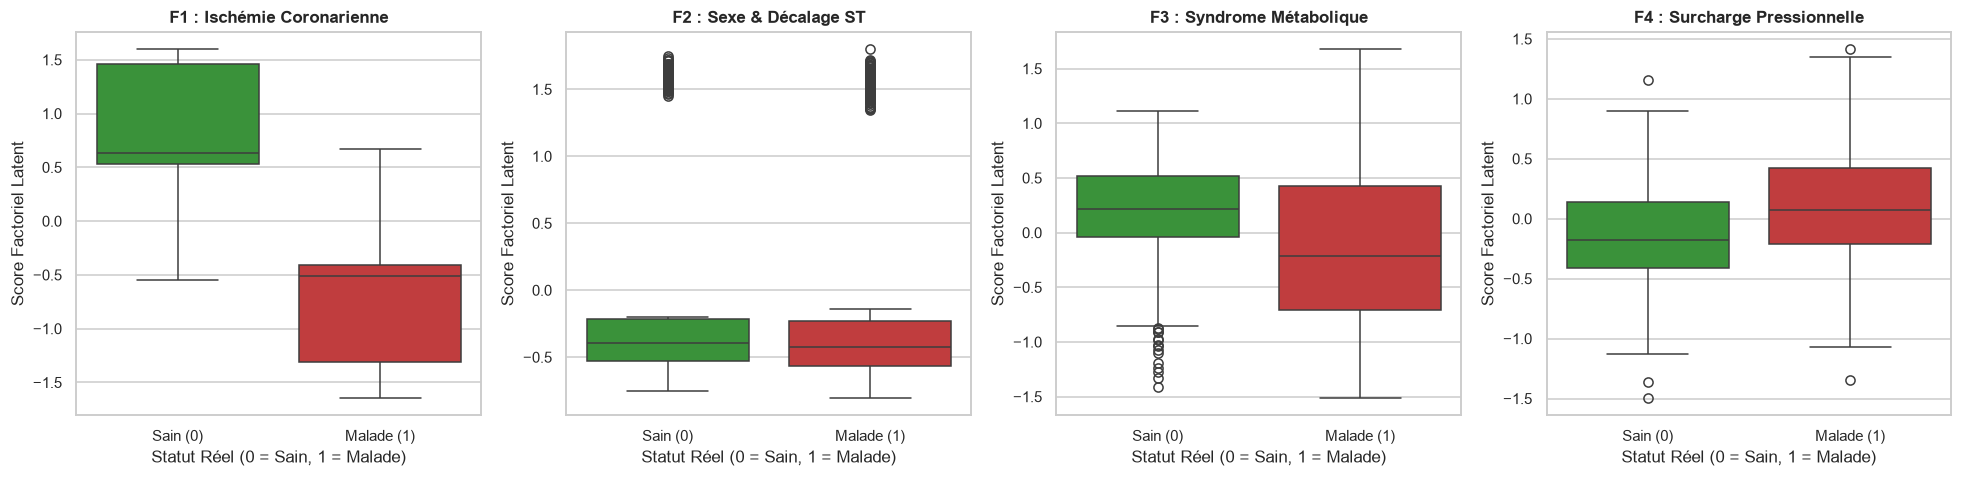

In [20]:
# Association statistique des scores factoriels avec la variable cible
factor_scores_df = pd.DataFrame(
    fa_transformed,
    columns=['Score_F1', 'Score_F2', 'Score_F3', 'Score_F4']
)
factor_scores_df['target'] = y_true.values

# Corrélations point-bisériales avec target
correlations_target = factor_scores_df.corr()['target'].drop('target')

print("=== CORRÉLATION DES SCORES FACTORIELS AVEC LA CIBLE (target) ===")
display(pd.DataFrame({
    'Corrélation r': correlations_target,
    'Association': ['Très Forte (Ischémie)', 'Modérée (Démographie)', 'Modérée (Métabolique)', 'Légère (Pression)']
}))

# Visualisation comparative des distributions par statut pathologique
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

factor_titles = [
    "F1 : Ischémie Coronarienne",
    "F2 : Sexe & Décalage ST",
    "F3 : Syndrome Métabolique",
    "F4 : Surcharge Pressionnelle"
]

for idx, col in enumerate(['Score_F1', 'Score_F2', 'Score_F3', 'Score_F4']):
    sns.boxplot(data=factor_scores_df, x='target', y=col, ax=axes[idx],
                palette=['#2ca02c', '#d62728'])
    axes[idx].set_title(factor_titles[idx], fontweight='bold', fontsize=11)
    axes[idx].set_xlabel("Statut Réel (0 = Sain, 1 = Malade)")
    axes[idx].set_ylabel("Score Factoriel Latent")
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Sain (0)', 'Malade (1)'])

plt.tight_layout()
plt.show()

---
## 4. Synthèse Multivariée & Passerelle vers la Modélisation Supervisée

### 4.1 Tableau Comparatif des Trois Approches Non Supervisées

| Dimension d'Analyse | K-Means Clustering | Analyse en Composantes Principales (PCA) | Analyse Factorielle Exploratoire (FA) |
| :--- | :--- | :--- | :--- |
| **Objectif Principal** | Identifier des sous-groupes discrets et homogènes de patients | Réduire la dimensionnalité en maximisant la variance globale | Révéler des construits latents continus non directement observés |
| **Nature Mathématique** | Partitionnement géométrique d'espace par distance euclidienne | Décomposition spectrale orthogonale (SVD / Eigendecomposition) | Modèle statistique génératif avec estimation de la variance commune |
| **Type de Variance** | Variance totale de dispersion des points | 100% de la variance des variables d'origine | Uniquement la variance partagée (communalités $h^2$) |
| **Résultat Principal** | 3 profils cliniques distincts : Haut Risque, Modéré, Faible Risque | 4 axes majeurs résumant > 51.4% de la variance (PC1 à PC4) | 4 syndromes médicaux nets (Ischémie, Métabolisme, Sexe/ST, Pression) |
| **Rôle en Modélisation** | Feature catégorielle (`cluster_id`) ou distance aux centroïdes | Décorrélation des prédicteurs, lutte contre la multicolinéarité | Variables synthétiques interprétables (scores factoriels $F_j$) |

### 4.2 Recommandations Opérationnelles pour la Phase de Modélisation Prédictive

Sur la base des enseignements univariés, bivariés et multivariés, voici les recommandations concrètes pour la phase de Machine Learning :

1. **Intégration des Découvertes Multivariées en Feature Engineering** :
   - **Feature de Cluster** : L'intégration de la variable catégorielle issue de K-Means (ou de la distance euclidienne relative au centroïde du Cluster 0 « Haut Risque ») fournira un puissant a priori non linéaire aux modèles supervisés.
   - **Scores Factoriels Métaboliques et Ischémiques** : L'utilisation des scores factoriels ($F_1$ et $F_3$) permettra d'injecter des indices cliniques agrégés hautement informatifs et décorrélés.

2. **Stratégie Face à la Multicolinéarité** :
   - Le diagnostic bivarié (Notebook 03) avait révélé des corrélations notables entre `oldpeak`, `slope`, `exerciseangia` et `chestpain`.
   - L'utilisation conjointe de la PCA permettra d'entraîner et de comparer des modèles linéaires régularisés (ex. Régression Logistique ElasticNet, Ridge) sur les composantes principales orthogonales, éliminant tout risque d'instabilité des coefficients.

3. **Prochaines Étapes du Projet** :
   - 📌 **Notebook 05** : Préparation finale des données & Feature Engineering (Imputation éventuelle des valeurs nulles de cholestérol, Encodage One-Hot des catégorielles nominales, Normalisation robuste).
   - 📌 **Notebook 06** : Entraînement et Sélection de Modèles Supervisés (Régression Logistique, Random Forest, XGBoost, LightGBM, CatBoost) avec validation croisée stratifiée.